# Actividad 5.4 - DBSCAN en datasets artificiales

En esta actividad se aplica **DBSCAN** a varios datasets artificiales del repositorio:

- https://github.com/deric/clustering-benchmark

Se escogen datasets con estructuras no convexas, donde **K-means** suele comportarse peor (por ejemplo, espirales o caminos curvos).

## Objetivos

1. Cargar varios datasets artificiales del benchmark.
2. Fijar un valor de `min_samples`.
3. Usar la **gráfica de codo k-distance** para estimar un `eps` apropiado.
4. Comparar visualmente **K-means vs DBSCAN**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN, KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

In [5]:
def _parse_arff_from_url(url: str):
    """Descarga un ARFF y devuelve su bloque de datos como DataFrame."""
    import io
    import requests

    response = requests.get(url, timeout=30)
    response.raise_for_status()

    lines = response.text.splitlines()
    data_start = None
    for idx, line in enumerate(lines):
        if line.strip().lower() == "@data":
            data_start = idx + 1
            break

    if data_start is None:
        raise ValueError("Archivo ARFF sin sección @data")

    data_lines = [ln.strip() for ln in lines[data_start:] if ln.strip() and not ln.strip().startswith("%")]
    data_text = "\n".join(data_lines)

    return pd.read_csv(io.StringIO(data_text), header=None)


def load_benchmark_dataset(name: str):
    """Carga un dataset artificial del repo clustering-benchmark desde GitHub raw."""
    base_candidates = [
        "https://raw.githubusercontent.com/deric/clustering-benchmark/master/src/main/resources/datasets/artificial",
        "https://raw.githubusercontent.com/deric/clustering-benchmark/main/src/main/resources/datasets/artificial",
    ]

    last_error = None
    for base in base_candidates:
        url = f"{base}/{name}.arff"
        try:
            df = _parse_arff_from_url(url)
            values = df.values

            # En estos datasets las dos primeras columnas son coordenadas 2D.
            X = values[:, :2].astype(float)
            y = values[:, 2] if values.shape[1] >= 3 else None
            return X, y, url
        except Exception as exc:
            last_error = exc

    raise RuntimeError(f"No se pudo cargar '{name}'. Error: {last_error}")


def estimate_eps_from_k_distance(X, min_samples=5):
    """Devuelve distancias k-ésimas ordenadas y una estimación automática simple de eps."""
    nn = NearestNeighbors(n_neighbors=min_samples)
    nn.fit(X)
    distances, _ = nn.kneighbors(X)

    # Distancia al vecino k para cada punto, ordenada ascendentemente.
    k_dist = np.sort(distances[:, -1])

    # Heurística de codo: máximo de la segunda derivada discreta.
    second_derivative = np.gradient(np.gradient(k_dist))
    eps_idx = int(np.argmax(second_derivative))
    eps_est = float(k_dist[eps_idx])

    return k_dist, eps_est, eps_idx


def safe_silhouette(X, labels):
    """Calcula silhouette evitando casos no válidos (ruido o un solo cluster)."""
    labels = np.asarray(labels)
    mask = labels != -1

    if mask.sum() < 3:
        return np.nan

    unique = np.unique(labels[mask])
    if len(unique) < 2:
        return np.nan

    return silhouette_score(X[mask], labels[mask])

In [6]:
def compare_kmeans_dbscan(name, min_samples=5, kmeans_k=None, eps_override=None):
    X, y_true, source_url = load_benchmark_dataset(name)

    # Si hay etiquetas reales, se usan para estimar K de K-means.
    if kmeans_k is None:
        if y_true is not None:
            kmeans_k = len(np.unique(y_true))
        else:
            kmeans_k = 3

    k_dist, eps_est, eps_idx = estimate_eps_from_k_distance(X, min_samples=min_samples)
    eps = eps_override if eps_override is not None else eps_est

    km = KMeans(n_clusters=kmeans_k, random_state=42, n_init=20)
    km_labels = km.fit_predict(X)

    db = DBSCAN(eps=eps, min_samples=min_samples)
    db_labels = db.fit_predict(X)

    km_sil = safe_silhouette(X, km_labels)
    db_sil = safe_silhouette(X, db_labels)

    n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
    n_noise = int(np.sum(db_labels == -1))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].scatter(X[:, 0], X[:, 1], s=12, c="steelblue", alpha=0.85)
    axes[0].set_title(f"Dataset: {name}")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")

    axes[1].plot(k_dist, color="darkorange", lw=2)
    axes[1].axhline(eps, color="crimson", ls="--", label=f"eps={eps:.3f}")
    axes[1].axvline(eps_idx, color="gray", ls=":", label=f"idx codo={eps_idx}")
    axes[1].set_title(f"k-distance (k = min_samples = {min_samples})")
    axes[1].set_xlabel("Puntos ordenados")
    axes[1].set_ylabel("Distancia al k-ésimo vecino")
    axes[1].legend()

    scatter = axes[2].scatter(X[:, 0], X[:, 1], c=db_labels, s=12, cmap="tab20", alpha=0.9)
    axes[2].set_title(f"DBSCAN: clusters={n_clusters_db}, ruido={n_noise}")
    axes[2].set_xlabel("x")
    axes[2].set_ylabel("y")

    plt.tight_layout()
    plt.show()

    print(f"Fuente: {source_url}")
    print(f"K-means (k={kmeans_k}) silhouette: {km_sil:.4f}")
    print(f"DBSCAN (eps={eps:.4f}, min_samples={min_samples}) silhouette (sin ruido): {db_sil:.4f}")
    print("-" * 80)

    return {
        "dataset": name,
        "kmeans_k": kmeans_k,
        "eps": eps,
        "min_samples": min_samples,
        "kmeans_silhouette": km_sil,
        "dbscan_silhouette": db_sil,
        "dbscan_clusters": n_clusters_db,
        "dbscan_noise_points": n_noise,
    }

## Selección de datasets y parámetros

Se usan tres datasets artificiales de formas no convexas:

- `spiral`
- `pathbased`
- `jain`

Fijamos `min_samples = 3` para todos.

Después, en cada dataset se observa la curva **k-distance** (con `k = min_samples`) y se escoge un `eps` manual en la zona de codo, evitando el último salto extremo de la cola de la curva.

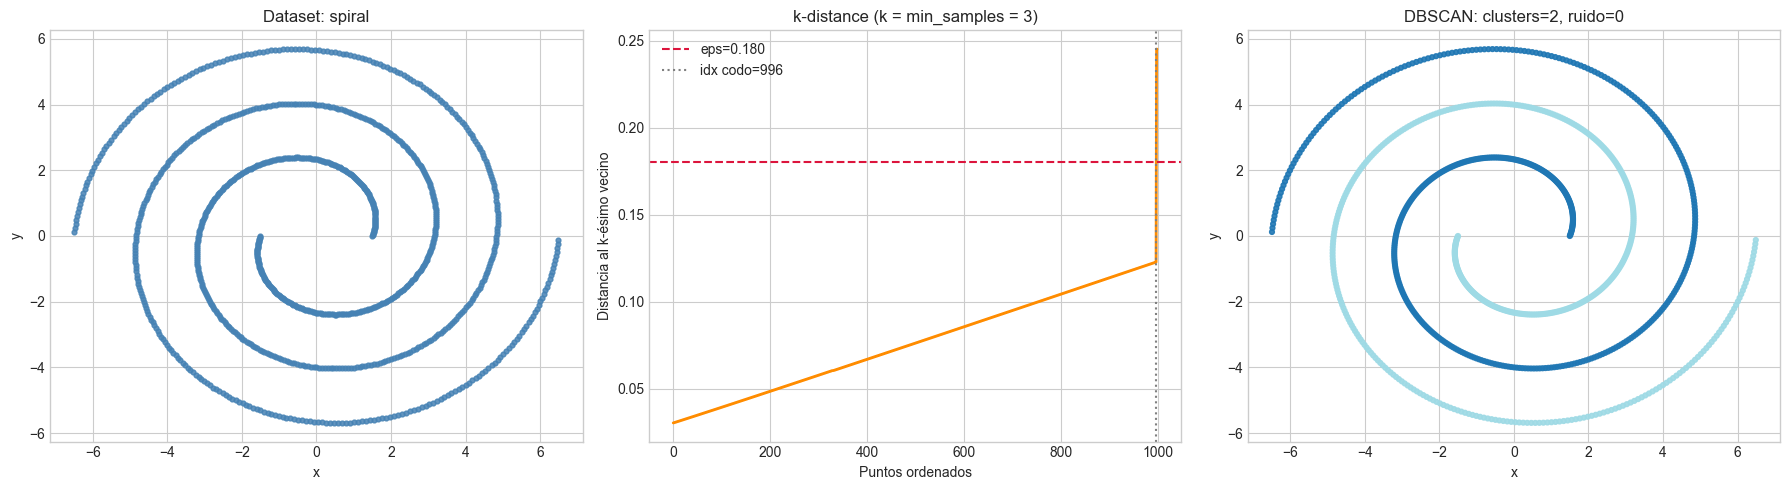

Fuente: https://raw.githubusercontent.com/deric/clustering-benchmark/master/src/main/resources/datasets/artificial/spiral.arff
K-means (k=2) silhouette: 0.3537
DBSCAN (eps=0.1800, min_samples=3) silhouette (sin ruido): 0.0407
--------------------------------------------------------------------------------


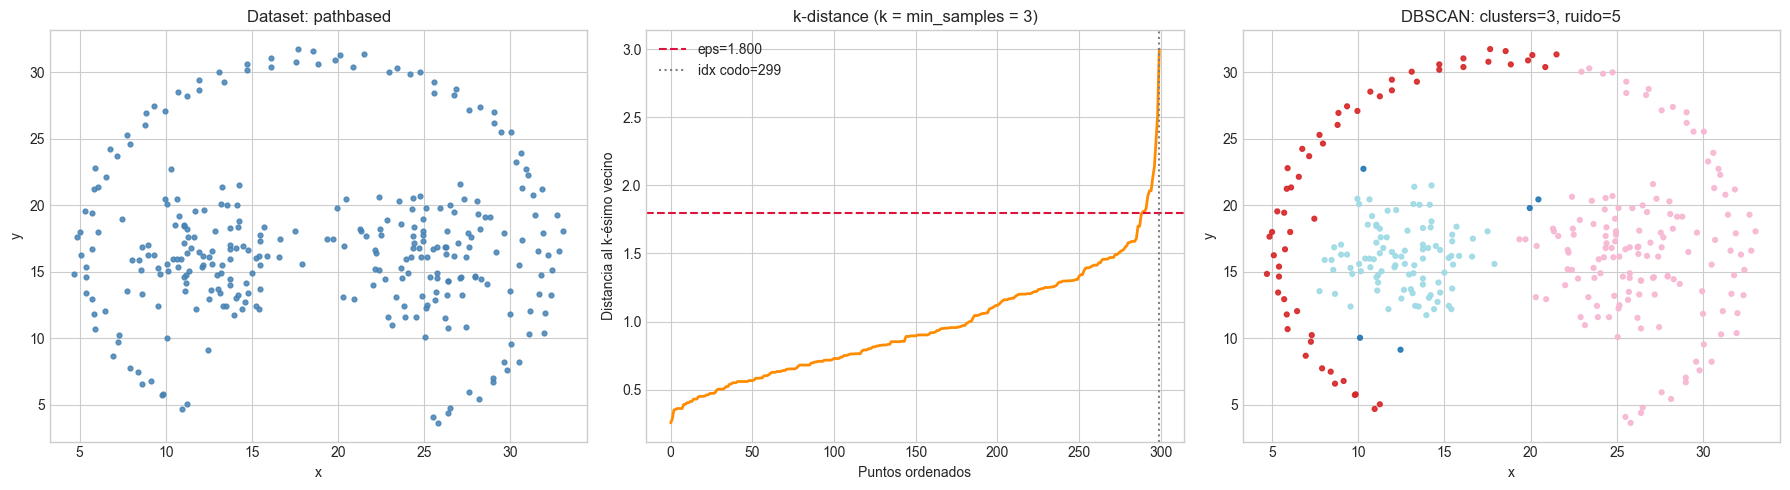

Fuente: https://raw.githubusercontent.com/deric/clustering-benchmark/master/src/main/resources/datasets/artificial/pathbased.arff
K-means (k=3) silhouette: 0.5419
DBSCAN (eps=1.8000, min_samples=3) silhouette (sin ruido): 0.4093
--------------------------------------------------------------------------------


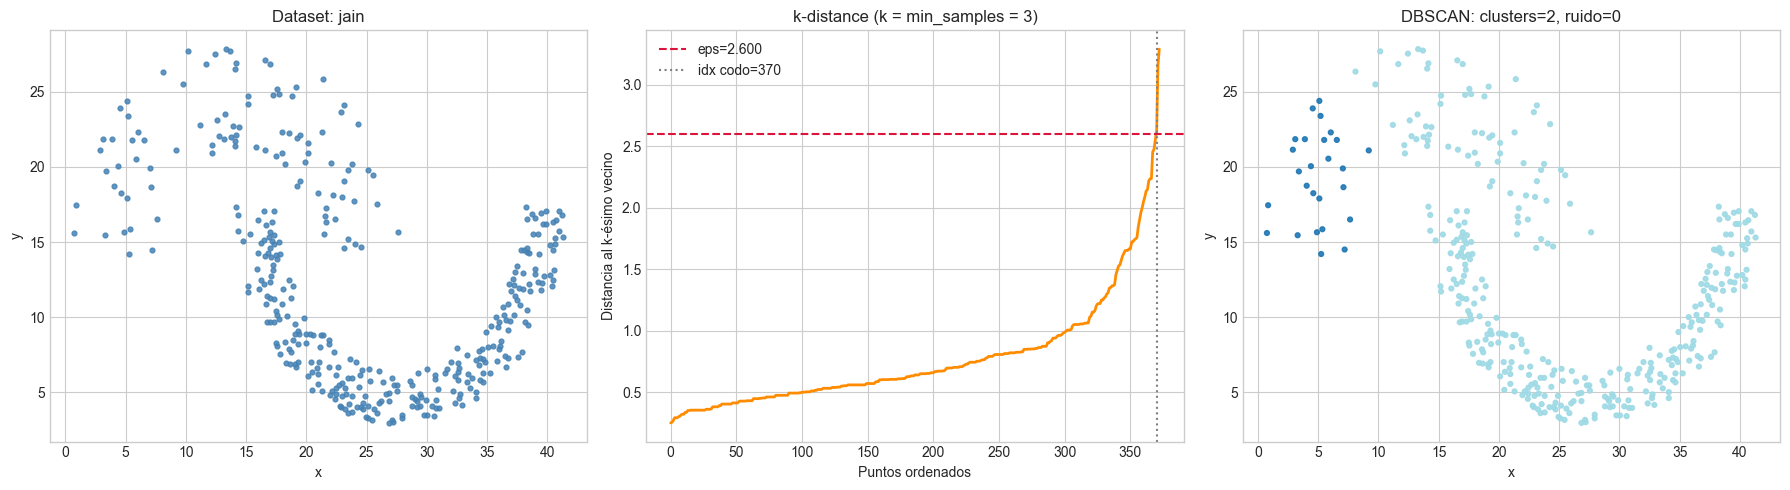

Fuente: https://raw.githubusercontent.com/deric/clustering-benchmark/master/src/main/resources/datasets/artificial/jain.arff
K-means (k=2) silhouette: 0.4952
DBSCAN (eps=2.6000, min_samples=3) silhouette (sin ruido): 0.3782
--------------------------------------------------------------------------------


,dataset,kmeans_k,eps,min_samples,kmeans_silhouette,dbscan_silhouette,dbscan_clusters,dbscan_noise_points
0,spiral,2,0.18,3,0.353747,0.040672,2,0
1,pathbased,3,1.80,3,0.541922,0.409281,3,5
2,jain,2,2.60,3,0.495231,0.378232,2,0


In [8]:
datasets = ["spiral", "pathbased", "jain"]
min_samples = 3

# eps elegidos por inspección visual de la gráfica k-distance (codo) en cada dataset.
eps_manual = {
    "spiral": 0.18,
    "pathbased": 1.80,
    "jain": 2.60,
}

results = []
for ds in datasets:
    results.append(
        compare_kmeans_dbscan(
            ds,
            min_samples=min_samples,
            eps_override=eps_manual[ds],
        )
    )

results_df = pd.DataFrame(results)
results_df

## Conclusiones

- En datasets con formas complejas/no convexas, K-means tiende a separar por proximidad a centroides y puede romper estructuras naturales.
- DBSCAN identifica mejor regiones densas conectadas, y además detecta ruido (etiqueta `-1`).
- La gráfica **k-distance** ayuda a elegir `eps`: el codo marca una transición entre vecindades densas y puntos más aislados.
- Ajustar `min_samples` y `eps` por dataset suele mejorar notablemente el resultado.